# Bile acid modifications across human and rodent body parts

**Produces:** Figure 1B and Supplementary Figure 2 (number of unique positive delta masses per body part, section *DELTAS*) and Supplementary Figure 3 (number of MS/MS scans per body part, section *SCANS*).

**Steps:** combine the six final library MGFs into one annotation table; trace every retained cluster back to its Falcon cluster members and their original repository file paths; compute delta masses relative to each core; merge with ReDU metadata (accessed 13 Aug 2025); keep positive deltas and drop spectra flagged as alternative ion forms (output of `SuppFig6_SuppFig7_alternative_ion_forms`); count per body part for humans (`9606|Homo sapiens`) and rodents (*Mus*/*Rattus*); draw bubble plots.

**Inputs:** final library MGFs, Falcon cluster CSVs, pre-Falcon annotation tables, ReDU metadata table, ion-form annotation tables.

**Note:** the plotting cells draw one core group at a time. Change `groups` (e.g. `['C23']`, `['C24']`, `['C24_alkamine']`, `['C26']`, `['C27']`, `['C28_alcohol']`), `my_colors` and `save_path` to produce each panel.

In [1]:
import os

# Root of the local project folder (the one holding Falcon/, Queries_final_mgf/,
# final_mgfs_library_generation/, ...). Edit this single line to run elsewhere.
PROJECT_DIR = '/media/dorrestein/Helena2/Bile_acids_update'

In [2]:
import pandas as pd

## Combine all libraries

In [3]:
mgf_libraries = {
    'C23_library': f'{PROJECT_DIR}/final_mgfs_library_generation/upload_GNPS/C23_library.mgf',
    'C24_library': f'{PROJECT_DIR}/final_mgfs_library_generation/upload_GNPS/C24_library.mgf',
    'C24_alkylamine_library': f'{PROJECT_DIR}/final_mgfs_library_generation/upload_GNPS/C24_alkylamine_library.mgf',
    'C26_library': f'{PROJECT_DIR}/final_mgfs_library_generation/upload_GNPS/C26_library.mgf',
    'C27_library': f'{PROJECT_DIR}/final_mgfs_library_generation/upload_GNPS/C27_library.mgf',
    'C28_alcohol_library': f'{PROJECT_DIR}/final_mgfs_library_generation/upload_GNPS/C28_alcohol_library.mgf',
}

In [4]:
# combine all the mgfs
output_path = f'{PROJECT_DIR}/body_part_distribution/combined_library.mgf'

global_scan = 0
counts = {}

with open(output_path, 'w') as out:
    for lib_name, path in mgf_libraries.items():
        start = global_scan
        with open(path) as f:
            scans_written = False
            for line in f:
                if line.startswith('BEGIN IONS'):
                    global_scan += 1
                    scans_written = False
                    out.write(line)
                elif line.startswith('SCANS='):
                    old = line.split('=', 1)[1].strip()
                    out.write(f'SCANS_INDIVIDUAL_LIBRARY={old}\n')
                    out.write(f'SCANS={global_scan}\n')
                    scans_written = True
                elif line.startswith('END IONS'):
                    if not scans_written:          # block had no SCANS line
                        out.write(f'SCANS={global_scan}\n')
                    if not line.endswith('\n'):     # guard file-boundary join
                        line += '\n'
                    out.write(line)
                else:
                    out.write(line)
        counts[lib_name] = (start + 1, global_scan)

print(f'Total spectra written: {global_scan}\n')
for lib, (lo, hi) in counts.items():
    print(f'{lib}: SCANS {lo}–{hi}')

Total spectra written: 640141

C23_library: SCANS 1–4442
C24_library: SCANS 4443–202570
C24_alkylamine_library: SCANS 202571–460060
C26_library: SCANS 460061–464245
C27_library: SCANS 464246–530998
C28_alcohol_library: SCANS 530999–640141


In [5]:
#annotation table

input_file = f'{PROJECT_DIR}/body_part_distribution/combined_library.mgf'

scan = []
scan_individual_library = []
cluster = []
pepmass = []
title = []

with open(input_file, 'rb') as fin:  # Open in binary mode
    input_lines = fin.readlines()

    for line in input_lines:
        decoded_line = line.decode('utf-8', errors='ignore')  # Decode using utf-8 with error handling
        if decoded_line.startswith('SCANS='):
            parts = decoded_line.strip().split('=')[1]
            scan.append(parts)
        if decoded_line.startswith('SCANS_INDIVIDUAL_LIBRARY='):
            parts = decoded_line.strip().split('=')[1]
            scan_individual_library.append(parts)
        if decoded_line.startswith('TITLE='):
            parts = decoded_line.strip().split('=')[1]
            title.append(parts)
        if decoded_line.startswith('CLUSTER='):
            parts = decoded_line.strip().split('=')[1]
            cluster.append(parts)
        elif decoded_line.startswith('PEPMASS='):
            parts = decoded_line.strip().split('=')[1]
            pepmass.append(parts)

        else:
            continue
            

df = pd.DataFrame()
df['scan'] = scan
df['scan_individual_lib'] = scan_individual_library
df['title'] = title
df['cluster'] = cluster
df['precmz'] = pepmass

df.to_csv(f'{PROJECT_DIR}/body_part_distribution/combined_library_annotation_table.tsv',
          sep='\t', index=False)

In [6]:
df = pd.read_csv(f'{PROJECT_DIR}/body_part_distribution/combined_library_annotation_table.tsv', sep='\t')

#create a standardize core column for matching with the falcon csv file
df['core'] = df['title'].str.split(':').str[2]

core_map = {
    'C23_Monohydroxy_input_falcon_charge': 'C23_monohydroxy',
    'C23_dihydroxy_input_falcon_charge': 'C23_dihydroxy',
    'C23_trihydroxy_input_falcon_charge': 'C23_trihydroxy',
    'C23_tetrahydroxy_input_falcon_charge': 'C23_tetrahydroxy',
    'C23_pentahydroxy_input_falcon_charge': 'C23_pentahydroxy',
    'C24_Nonhydroxy_input_falcon_charge': 'C24_nonhydroxy',
    'C24_monohydroxy_input_falcon_charge': 'C24_monohydroxy',
    'C24_dihydroxy_input_falcon_charge': 'C24_dihydroxy',
    'C24_Trihydroxy_input_falcon_charge_part1': 'C24_trihydroxy_part1',
    'C24_Trihydroxy_input_falcon_charge_part2': 'C24_trihydroxy_part2',
    'C24_Trihydroxy_input_falcon_charge_part3': 'C24_trihydroxy_part3',
    'C24_tetrahydroxy_input_falcon_charge': 'C24_tetrahydroxy',
    'C24_pentahydroxy_input_falcon_charge': 'C24_pentahydroxy',
    'C24_alkylamine_monohydroxy_input_falcon_charge': 'C24_alkylamine_monohydroxy',
    'C24_alkylamine_dihydroxy_input_falcon_charge': 'C24_alkylamine_dihydroxy',
    'C24_alkylamine_trihydroxy_input_falcon_charge_part1': 'C24_alkylamine_trihydroxy_part1',
    'C24_alkylamine_trihydroxy_input_falcon_charge_part2': 'C24_alkylamine_trihydroxy_part2',
    'C24_alkylamine_trihydroxy_input_falcon_charge_part3': 'C24_alkylamine_trihydroxy_part3',
    'C24_alkylamine_trihydroxy_input_falcon_charge_part4': 'C24_alkylamine_trihydroxy_part4',
    'C24_alkylamine_tetrahydroxy_input_falcon_charge': 'C24_alkylamine_tetrahydroxy',
    'C24_alkylamine_pentahydroxy_input_falcon_charge': 'C24_alkylamine_pentahydroxy',
    'Aceto_dihydroxy_input_falcon_charge_renumbered': 'Aceto_dihydroxy',
    'C27_monohydroxy_input_falcon_charge': 'C27_monohydroxy',
    'C27_dihydroxy_input_falcon_charge': 'C27_dihydroxy',
    'C27_trihydroxy_input_falcon_charge': 'C27_trihydroxy',
    'C27_tetrahydroxy_input_falcon_charge': 'C27_tetrahydroxy',
    'C27_pentahydroxy_input_falcon_charge': 'C27_pentahydroxy',
    'C28_alcohol_1OH_input_falcon_351_C28O1_charge': 'C28_alcohol_1OH',
    'C28_alcohol_2OH_input_falcon_367_C28O2_charge': 'C28_alcohol_2OH',
    'C28_alcohol_3OH_input_falcon_383_C28O3_charge': 'C28_alcohol_3OH',
}

df['core_std'] = df['core'].map(core_map)

## Post-Falcon results

In [7]:
post_falcon = {
    'C24_nonhydroxy': f'{PROJECT_DIR}/Queries_final_mgf/C24_final/Nonhydroxy/falcon_output/C24_nonhydroxy_falcon_eps01_minsamples2.csv',
    'C24_monohydroxy': f'{PROJECT_DIR}/Queries_final_mgf/C24_final/Monohydroxy/falcon_output/C24_monohydroxy_falcon_eps01_minsamples2.csv',
    'C24_dihydroxy': f'{PROJECT_DIR}/Queries_final_mgf/C24_final/Dihydroxy/falcon_output/C24_dihydroxy_falcon_eps01_minsamples2.csv',
    'C24_trihydroxy_part1': f'{PROJECT_DIR}/Queries_final_mgf/C24_final/Trihydroxy/falcon_output/C24_final_trihydroxy_part1_falcon_eps01_minsamples2.csv',
    'C24_trihydroxy_part2': f'{PROJECT_DIR}/Queries_final_mgf/C24_final/Trihydroxy/falcon_output/C24_final_trihydroxy_part2_falcon_eps01_minsamples2.csv',
    'C24_trihydroxy_part3': f'{PROJECT_DIR}/Queries_final_mgf/C24_final/Trihydroxy/falcon_output/C24_final_trihydroxy_part3_falcon_eps01_minsamples2.csv',
    'C24_tetrahydroxy': f'{PROJECT_DIR}/Queries_final_mgf/C24_final/Tetrahydroxy/falcon_output/C24_tetrahydroxy_falcon_eps01_minsamples2.csv',
    'C24_pentahydroxy': f'{PROJECT_DIR}/Queries_final_mgf/C24_final/Pentahydroxy/falcon_output/C24_pentahydroxy_falcon_eps01_minsamples2.csv',

    "C23_monohydroxy": f'{PROJECT_DIR}/Queries_final_mgf/C23/C23_monohydroxy/falcon_output/C23_monohydroxy_falcon_eps01_minsamples2.csv',
    "C23_dihydroxy": f'{PROJECT_DIR}/Queries_final_mgf/C23/C23_dihydroxy/falcon_output/C23_dihydroxy_falcon_eps01_minsamples2.csv',
    "C23_trihydroxy": f'{PROJECT_DIR}/Queries_final_mgf/C23/C23_trihydroxy/falcon_output/C23_trihydroxy_falcon_eps01_minsamples2.csv',
    "C23_tetrahydroxy": f'{PROJECT_DIR}/Queries_final_mgf/C23/C23_tetrahydroxy/falcon_output/C23_tetrahydroxy_falcon_eps01_minsamples2.csv',
    "C23_pentahydroxy": f'{PROJECT_DIR}/Queries_final_mgf/C23/C23_pentahydroxy/falcon_output/C23_pentahydroxy_falcon_eps01_minsamples2.csv',

    "C27_monohydroxy": f'{PROJECT_DIR}/Queries_final_mgf/C27/C27_monohydroxy/falcon_output/C27_monohydroxy_falcon_eps01_minsamples2.csv',
    "C27_dihydroxy": f'{PROJECT_DIR}/Queries_final_mgf/C27/C27_dihydroxy/falcon_output/C27_dihydroxy_falcon_eps01_minsamples2.csv',
    "C27_trihydroxy": f'{PROJECT_DIR}/Queries_final_mgf/C27/C27_trihydroxy/falcon_output/C27_trihydroxy_falcon_eps01_minsamples2.csv',
    "C27_tetrahydroxy": f'{PROJECT_DIR}/Queries_final_mgf/C27/C27_tetrahydroxy/falcon_output/C27_tetrahydroxy_falcon_eps01_minsamples2.csv',
    "C27_pentahydroxy": f'{PROJECT_DIR}/Queries_final_mgf/C27/C27_pentahydroxy/falcon_output/C27_pentahydroxy_falcon_eps01_minsamples2.csv',

    "Aceto_dihydroxy": f'{PROJECT_DIR}/Queries_final_mgf/Aceto/Dihydroxy/falcon_output/aceto_dihydroxy_falcon_eps01_minsamples2.csv',

    "C24_alkylamine_monohydroxy": f'{PROJECT_DIR}/Queries_final_mgf/C24_alkylamine/C24_alkylamine_monohydroxy/falcon_output/C24_alkylamine_monohydroxy_falcon_eps01_minsamples2.csv',
    "C24_alkylamine_dihydroxy": f'{PROJECT_DIR}/Queries_final_mgf/C24_alkylamine/C24_alkylamine_dihydroxy/falcon_output/C24_alkylamine_dihydroxy_falcon_eps01_minsamples2.csv',
    "C24_alkylamine_trihydroxy_part1": f'{PROJECT_DIR}/Queries_final_mgf/C24_alkylamine/C24_alkylamine_trihydroxy/falcon_output/C24_alkylamine_trihydroxy_part1_falcon_eps01_minsamples2.csv',
    "C24_alkylamine_trihydroxy_part2": f'{PROJECT_DIR}/Queries_final_mgf/C24_alkylamine/C24_alkylamine_trihydroxy/falcon_output/C24_alkylamine_trihydroxy_part2_falcon_eps01_minsamples2.csv',
    "C24_alkylamine_trihydroxy_part3": f'{PROJECT_DIR}/Queries_final_mgf/C24_alkylamine/C24_alkylamine_trihydroxy/falcon_output/C24_alkylamine_trihydroxy_part3_falcon_eps01_minsamples2.csv',
    "C24_alkylamine_trihydroxy_part4": f'{PROJECT_DIR}/Queries_final_mgf/C24_alkylamine/C24_alkylamine_trihydroxy/falcon_output/C24_alkylamine_trihydroxy_part4_falcon_eps01_minsamples2.csv',
    "C24_alkylamine_tetrahydroxy": f'{PROJECT_DIR}/Queries_final_mgf/C24_alkylamine/C24_alkylamine_tetrahydroxy/falcon_output/C24_alkylamine_tetrahydroxy_falcon_eps01_minsamples2.csv',
    "C24_alkylamine_pentahydroxy": f'{PROJECT_DIR}/Queries_final_mgf/C24_alkylamine/C24_alkylamine_pentahydroxy/falcon_output/C24_alkylamine_pentahydroxy_falcon_eps01_minsamples2.csv',

    "C28_alcohol_1OH": f'{PROJECT_DIR}/Queries_final_mgf/C28_alcohol/One_OH/falcon_output/C28_alcohol_1OH_falcon_eps01_minsamples2.csv',
    "C28_alcohol_2OH": f'{PROJECT_DIR}/Queries_final_mgf/C28_alcohol/Two_OH/falcon_output/C28_alcohol_2OH_falcon_eps01_minsamples2.csv',
    "C28_alcohol_3OH": f'{PROJECT_DIR}/Queries_final_mgf/C28_alcohol/Three_OH/falcon_output/C28_alcohol_3OH_falcon_eps01_minsamples2.csv'
}

In [8]:
# loop through all of the falcon output files and add a column with the core structure, then combine into one dataframe
import pandas as pd

frames = []
for core_std, path in post_falcon.items():
    d = pd.read_csv(path, skiprows=25)
    d['core_std'] = core_std
    frames.append(d)

combined_falcon = pd.concat(frames, ignore_index=True)

In [9]:
#merge

# create a core_std_cluster for both dataframes we want to merge
combined_falcon['core_std_cluster'] = (
    combined_falcon['core_std'] + '_' + combined_falcon['cluster'].astype(str)
)
df['core_std_cluster'] = df['core_std'] + '_' + df['cluster'].astype(str)

merged = pd.merge(
    df,
    combined_falcon.drop(columns=['cluster', 'core_std']),
    on='core_std_cluster',
    how='left'
)

#these are the scan numbers we need to know to rescue from the pre-falcon annotation tables

## Pre-Falcon tables

In [10]:
pre_falcon = {
    'C24_nonhydroxy': f'{PROJECT_DIR}/Queries_final_mgf/C24_final/Nonhydroxy/download_mgfs/final_mgf/C24_Nonhydroxy_input_falcon_charge_annotation_table.tsv',
    'C24_monohydroxy': f'{PROJECT_DIR}/Queries_final_mgf/C24_final/Monohydroxy/download_mgfs/final_mgf/C24_Monohydroxy_input_falcon_charge_annotation_table.tsv',
    'C24_dihydroxy': f'{PROJECT_DIR}/Queries_final_mgf/C24_final/Dihydroxy/download_mgfs/final_mgf/C24_dihydroxy_input_falcon_charge_annotation_table.tsv',
    'C24_trihydroxy_part1': f'{PROJECT_DIR}/Queries_final_mgf/C24_final/Trihydroxy/download_mgfs/final_mgf/C24_Trihydroxy_input_falcon_charge_part1_annotation_table.tsv',
    'C24_trihydroxy_part2': f'{PROJECT_DIR}/Queries_final_mgf/C24_final/Trihydroxy/download_mgfs/final_mgf/C24_Trihydroxy_input_falcon_charge_part2_annotation_table.tsv',
    'C24_trihydroxy_part3': f'{PROJECT_DIR}/Queries_final_mgf/C24_final/Trihydroxy/download_mgfs/final_mgf/C24_Trihydroxy_input_falcon_charge_part3_annotation_table.tsv',
    'C24_tetrahydroxy': f'{PROJECT_DIR}/Queries_final_mgf/C24_final/Tetrahydroxy/download_mgfs/final_mgf/C24_Tetrahydroxy_input_falcon_charge_annotation_table.tsv',
    'C24_pentahydroxy': f'{PROJECT_DIR}/Queries_final_mgf/C24_final/Pentahydroxy/download_mgfs/final_mgf/C24_Pentahydroxy_input_falcon_charge_annotation_table.tsv',

    "C23_monohydroxy": f'{PROJECT_DIR}/Queries_final_mgf/C23/C23_monohydroxy/download_mgfs/final_mgf/C23_Monohydroxy_input_falcon_charge_annotation_table.tsv',
    "C23_dihydroxy": f'{PROJECT_DIR}/Queries_final_mgf/C23/C23_dihydroxy/download_mgfs/final_mgf/C23_dihydroxy_input_falcon_charge_annotation_table.tsv',
    "C23_trihydroxy": f'{PROJECT_DIR}/Queries_final_mgf/C23/C23_trihydroxy/download_mgfs/final_mgf/C23_trihydroxy_input_falcon_charge_annotation_table.tsv',
    "C23_tetrahydroxy": f'{PROJECT_DIR}/Queries_final_mgf/C23/C23_tetrahydroxy/download_mgfs/final_mgf/C23_tetrahydroxy_input_falcon_charge_annotation_table.tsv',
    "C23_pentahydroxy": f'{PROJECT_DIR}/Queries_final_mgf/C23/C23_pentahydroxy/download_mgfs/final_mgf/C23_pentahydroxy_input_falcon_charge_annotation_table.tsv',

    "C27_monohydroxy": f'{PROJECT_DIR}/Queries_final_mgf/C27/C27_monohydroxy/download_mgfs/final_mgf/C27_monohydroxy_input_falcon_charge_annotation_table.tsv',
    "C27_dihydroxy": f'{PROJECT_DIR}/Queries_final_mgf/C27/C27_dihydroxy/download_mgfs/final_mgf/C27_dihydroxy_input_falcon_charge_annotation_table.tsv',
    "C27_trihydroxy": f'{PROJECT_DIR}/Queries_final_mgf/C27/C27_trihydroxy/download_mgfs/final_mgf/C27_trihydroxy_input_falcon_charge_annotation_table.tsv',
    "C27_tetrahydroxy": f'{PROJECT_DIR}/Queries_final_mgf/C27/C27_tetrahydroxy/download_mgfs/final_mgf/C27_tetrahydroxy_input_falcon_charge_annotation_table.tsv',
    "C27_pentahydroxy": f'{PROJECT_DIR}/Queries_final_mgf/C27/C27_pentahydroxy/download_mgfs/final_mgf/C27_pentahydroxy_input_falcon_charge_annotation_table.tsv',

    "Aceto_dihydroxy": f'{PROJECT_DIR}/Queries_final_mgf/Aceto/Dihydroxy/download_mgfs/final_mgf/Aceto_dihydroxy_input_falcon_charge_renumbered_annotation_table.tsv',

    "C24_alkylamine_monohydroxy": f'{PROJECT_DIR}/Queries_final_mgf/C24_alkylamine/C24_alkylamine_monohydroxy/download_mgfs/final_mgf/C24_alkylamine_monohydroxy_input_falcon_charge_annotation_table.tsv',
    "C24_alkylamine_dihydroxy": f'{PROJECT_DIR}/Queries_final_mgf/C24_alkylamine/C24_alkylamine_dihydroxy/download_mgfs/final_mgf/C24_alkylamine_dihydroxy_input_falcon_charge_annotation_table.tsv',
    "C24_alkylamine_trihydroxy_part1": f'{PROJECT_DIR}/Queries_final_mgf/C24_alkylamine/C24_alkylamine_trihydroxy/download_mgfs/final_mgf/C24_alkylamine_trihydroxy_input_falcon_charge_part1_annotation_table.tsv',
    "C24_alkylamine_trihydroxy_part2": f'{PROJECT_DIR}/Queries_final_mgf/C24_alkylamine/C24_alkylamine_trihydroxy/download_mgfs/final_mgf/C24_alkylamine_trihydroxy_input_falcon_charge_part2_annotation_table.tsv',
    "C24_alkylamine_trihydroxy_part3": f'{PROJECT_DIR}/Queries_final_mgf/C24_alkylamine/C24_alkylamine_trihydroxy/download_mgfs/final_mgf/C24_alkylamine_trihydroxy_input_falcon_charge_part3_annotation_table.tsv',
    "C24_alkylamine_trihydroxy_part4": f'{PROJECT_DIR}/Queries_final_mgf/C24_alkylamine/C24_alkylamine_trihydroxy/download_mgfs/final_mgf/C24_alkylamine_trihydroxy_input_falcon_charge_part4_annotation_table.tsv',
    "C24_alkylamine_tetrahydroxy": f'{PROJECT_DIR}/Queries_final_mgf/C24_alkylamine/C24_alkylamine_tetrahydroxy/download_mgfs/final_mgf/C24_alkylamine_tetrahydroxy_input_falcon_charge_annotation_table.tsv',
    "C24_alkylamine_pentahydroxy": f'{PROJECT_DIR}/Queries_final_mgf/C24_alkylamine/C24_alkylamine_pentahydroxy/download_mgfs/final_mgf/C24_alkylamine_pentahydroxy_input_falcon_charge_annotation_table.tsv',

    "C28_alcohol_1OH": f'{PROJECT_DIR}/Queries_final_mgf/C28_alcohol/One_OH/download_mgfs/final_mgf/C28_alcohol_1OH_input_falcon_351_C28O1_charge_annotation_table.tsv',
    "C28_alcohol_2OH": f'{PROJECT_DIR}/Queries_final_mgf/C28_alcohol/Two_OH/download_mgfs/final_mgf/C28_alcohol_2OH_input_falcon_367_C28O2_charge_annotation_table.tsv',
    "C28_alcohol_3OH": f'{PROJECT_DIR}/Queries_final_mgf/C28_alcohol/Three_OH/download_mgfs/final_mgf/C28_alcohol_3OH_input_falcon_383_C28O3_charge_annotation_table.tsv',
}

In [11]:
#create an identifier column and combine all of them with another column specifying from where the rows came from

import os
import pandas as pd

all_dfs = []

for name, path in pre_falcon.items():
    df = pd.read_csv(path, sep='\t')
    df.columns = df.columns.str.strip()

    # filename without the '_annotation_table.tsv' part
    file_stem = os.path.basename(path).replace('_annotation_table.tsv', '')

    # 1) build the identifier column
    df['identifier'] = ('mzspec:USI000000:' + file_stem
                        + ':scan:' + df['scan_combined_mgf'].astype(str))

    # 2) tag with the dictionary key (name of the dataframe)
    df['source'] = name

    all_dfs.append(df)

combined_pre_falcon = pd.concat(all_dfs, ignore_index=True)
print(f"Combined {len(all_dfs)} tables -> {len(combined_pre_falcon)} rows")

# make some small adjusments for successful merge after
combined_pre_falcon['identifier'] = combined_pre_falcon['identifier'].str.replace(
    'C24_Monohydroxy_input_falcon_charge',
    'C24_monohydroxy_input_falcon_charge',
    regex=False
)

combined_pre_falcon['identifier'] = combined_pre_falcon['identifier'].str.replace(
    'C24_Pentahydroxy_input_falcon_charge',
    'C24_pentahydroxy_input_falcon_charge',
    regex=False
)

combined_pre_falcon['identifier'] = combined_pre_falcon['identifier'].str.replace(
    'C24_Tetrahydroxy_input_falcon_charge',
    'C24_tetrahydroxy_input_falcon_charge',
    regex=False
)

combined_pre_falcon['origin_repository'] = combined_pre_falcon['origin_repository'].str.strip()

Combined 30 tables -> 8278653 rows


In [12]:
#merge
merged_final = pd.merge(merged, combined_pre_falcon[['identifier', 'original_path', 'origin_repository']], on='identifier', how='left')

#export
merged_final.to_csv(f'{PROJECT_DIR}/body_part_distribution/merged_original_filepaths.tsv', sep='\t', index=False)

## Deltas calculation

In [13]:
deltas_calculation = {
    "C24_nonhydroxy": 361.3101,
    "C24_monohydroxy": 377.305,
    "C24_dihydroxy": 393.2999,
    "C24_trihydroxy_part1": 409.2949,
    "C24_trihydroxy_part2": 409.2949,
    "C24_trihydroxy_part3": 409.2949,
    "C24_tetrahydroxy": 425.2898,
    "C24_pentahydroxy": 441.2847,

    "C23_monohydroxy": 363.2894,
    "C23_dihydroxy": 379.2843,
    "C23_trihydroxy": 395.2792,
    "C23_tetrahydroxy": 411.2741,
    "C23_pentahydroxy": 427.269,

    "C27_monohydroxy": 419.352,
    "C27_dihydroxy": 435.3469,
    "C27_trihydroxy": 451.3418,
    "C27_tetrahydroxy": 467.3367,
    "C27_pentahydroxy": 483.3316,

    "Aceto_dihydroxy": 435.3105,

    "C24_alkylamine_monohydroxy": 377.305,
    "C24_alkylamine_dihydroxy": 393.2999,
    "C24_alkylamine_trihydroxy_part1": 409.2949,
    "C24_alkylamine_trihydroxy_part2": 409.2949,
    "C24_alkylamine_trihydroxy_part3": 409.2949,
    "C24_alkylamine_trihydroxy_part4": 409.2949,
    "C24_alkylamine_tetrahydroxy": 425.2898,
    "C24_alkylamine_pentahydroxy": 441.2847,
}

In [14]:
import pandas as pd

#import the table with all the filepaths from the pre-falcon annotation tables
df = pd.read_csv(f'{PROJECT_DIR}/body_part_distribution/merged_original_filepaths.tsv', sep='\t')

df['delta_mass'] = df['precmz'] - df['core_std'].map(deltas_calculation)
df['delta_round'] = df['delta_mass'].round(2)

## Merge with ReDU

In [15]:
import pandas as pd

#make sure there are no leading or trailing spaces in the 'original_path' column
df['original_path'] = df['original_path'].str.strip()
#create a filepath column
df['dataset'] = df['original_path'].str.split('/').str[2]
df['filename'] = df['original_path'].str.split('/').str[-1]
df['filename'] = df['filename'].str.rsplit('.', n=1).str[0]
df['filepath'] = df['dataset'] + '/' + df['filename']

In [16]:
### Import ReDU
df_redu = pd.read_csv(f'{PROJECT_DIR}/all_sampleinformation_ReDU_Sep13_2025.tsv', sep='\t')

#create a filepath column
df_redu['filename'] = df_redu['filename'].str.replace('f.', '')
df_redu['filename_2'] = df_redu['filename'].str.split('/').str[-1]
df_redu['filename_2'] = df_redu['filename_2'].str.rsplit('.', n=1).str[0]
df_redu['filepath'] = df_redu['ATTRIBUTE_DatasetAccession'] + '/' + df_redu['filename_2']

#merge
redu_merged = pd.merge(df, df_redu[['filepath', 'UBERONBodyPartName', 'NCBITaxonomy', 
                                    'AgeInYears', 'BiologicalSex', 'HealthStatus', 
                                    'DOIDCommonName']], on='filepath', how='left')

/tmp/ipykernel_305358/1562579000.py:2: DtypeWarning: Columns (5,25,27,28,29,34,35,36,37,38) have mixed types. Specify dtype option on import or set low_memory=False.
  df_redu = pd.read_csv(f'{PROJECT_DIR}/all_sampleinformation_ReDU_Sep13_2025.tsv', sep='\t')


In [17]:
#export
redu_merged.to_csv(f'{PROJECT_DIR}/body_part_distribution/merged_filepaths_redu_metadata.tsv', sep='\t', index=False)

# DELTAS

### Consider positive deltas only and no artifacts

In [18]:
import pandas as pd

redu_merged = pd.read_csv(f'{PROJECT_DIR}/body_part_distribution/merged_filepaths_redu_metadata.tsv', sep='\t')

In [19]:
redu_merged = redu_merged[redu_merged['delta_round'] > 0]

#import all the artifact files
c23_artifacts = pd.read_csv(f'{PROJECT_DIR}/Scripts_data_analysis/ISF_evaluation/TSV_and_HTML_files_artifacts/cores_combined_6_total/C23_combined_annotated_artifacts.tsv', sep='\t').drop_duplicates()
c24_artifacts = pd.read_csv(f'{PROJECT_DIR}/Scripts_data_analysis/ISF_evaluation/TSV_and_HTML_files_artifacts/cores_combined_6_total/C24_combined_annotated_artifacts.tsv', sep='\t').drop_duplicates()
c24_alkamine_artifacts = pd.read_csv(f'{PROJECT_DIR}/Scripts_data_analysis/ISF_evaluation/TSV_and_HTML_files_artifacts/cores_combined_6_total/C24_alkylamine_combined_annotated_artifacts.tsv', sep='\t').drop_duplicates()
c26_artifacts = pd.read_csv(f'{PROJECT_DIR}/Scripts_data_analysis/ISF_evaluation/TSV_and_HTML_files_artifacts/cores_combined_6_total/Aceto_combined_annotated_artifacts.tsv', sep='\t').drop_duplicates()
c27_artifacts = pd.read_csv(f'{PROJECT_DIR}/Scripts_data_analysis/ISF_evaluation/TSV_and_HTML_files_artifacts/cores_combined_6_total/C27_combined_annotated_artifacts.tsv', sep='\t').drop_duplicates()
c28_artifacts = pd.read_csv(f'{PROJECT_DIR}/Scripts_data_analysis/ISF_evaluation/TSV_and_HTML_files_artifacts/cores_combined_6_total/C28_alcohol_combined_annotated_artifacts.tsv', sep='\t').drop_duplicates()

#combine all of them vertically
artifacts_combined = pd.concat([c23_artifacts, c24_artifacts, c24_alkamine_artifacts, c26_artifacts, c27_artifacts, c28_artifacts], axis=0)

redu_merged = pd.merge(redu_merged, artifacts_combined[['identifier','is_artifact']], how='left', on=['identifier'])

#keep only the ones that are False (not artifacts)
redu_merged = redu_merged[redu_merged['is_artifact'] == False]

#drop duplicates
redu_merged = redu_merged.drop_duplicates()

/tmp/ipykernel_305358/1403764357.py:6: DtypeWarning: Columns (21) have mixed types. Specify dtype option on import or set low_memory=False.
  c24_alkamine_artifacts = pd.read_csv(f'{PROJECT_DIR}/Scripts_data_analysis/ISF_evaluation/TSV_and_HTML_files_artifacts/cores_combined_6_total/C24_alkylamine_combined_annotated_artifacts.tsv', sep='\t').drop_duplicates()


In [20]:
#create a column with BA class and delta mass rounded
redu_merged['BA_core_delta'] = redu_merged['core_std'] + '_' + redu_merged['delta_round'].astype(str)

#rename the ones that had to be split
redu_merged['core_std'] = redu_merged['core_std'].replace({
    'C24_trihydroxy_part1': 'C24_trihydroxy',
    'C24_trihydroxy_part2': 'C24_trihydroxy',
    'C24_trihydroxy_part3': 'C24_trihydroxy',
    'C24_alkylamine_trihydroxy_part1': 'C24_alkylamine_trihydroxy',
    'C24_alkylamine_trihydroxy_part2': 'C24_alkylamine_trihydroxy',
    'C24_alkylamine_trihydroxy_part3': 'C24_alkylamine_trihydroxy',
    'C24_alkylamine_trihydroxy_part4': 'C24_alkylamine_trihydroxy',
})

#split humans and rodents
#Humans
df_humans = redu_merged.loc[redu_merged['NCBITaxonomy'] == '9606|Homo sapiens']

#Rodents
list_rattus_mus = ['10088|Mus','10090|Mus musculus','10105|Mus minutoides','10114|Rattus','10116|Rattus norvegicus']
df_rodents = redu_merged[redu_merged['NCBITaxonomy'].isin(list_rattus_mus)]

In [21]:
counts_humans = (
    df_humans.groupby(["UBERONBodyPartName", "BA_core_delta"])
      .size()
      .reset_index(name="count")
)

counts_rodents = (
    df_rodents.groupby(["UBERONBodyPartName", "BA_core_delta"])
      .size()
      .reset_index(name="count")
)

In [22]:
counts_humans['core_std'] = counts_humans['BA_core_delta'].str.rsplit('_', n=1).str[0]

counts_humans['core_std'] = counts_humans['core_std'].replace({
    'C24_trihydroxy_part1': 'C24_trihydroxy',
    'C24_trihydroxy_part2': 'C24_trihydroxy',
    'C24_trihydroxy_part3': 'C24_trihydroxy',
    'C24_alkylamine_trihydroxy_part1': 'C24_alkylamine_trihydroxy',
    'C24_alkylamine_trihydroxy_part2': 'C24_alkylamine_trihydroxy',
    'C24_alkylamine_trihydroxy_part3': 'C24_alkylamine_trihydroxy',
    'C24_alkylamine_trihydroxy_part4': 'C24_alkylamine_trihydroxy',
})

counts_humans['delta_round'] = counts_humans['BA_core_delta'].str.split('_').str[-1]
counts_humans = counts_humans.drop(columns=['BA_core_delta', 'count'])

# define the exact order you want
col_order = [
    'C23_monohydroxy', 'C23_dihydroxy', 'C23_trihydroxy',
    'C23_tetrahydroxy', 'C23_pentahydroxy', 'C24_nonhydroxy',
    'C24_monohydroxy', 'C24_dihydroxy', 'C24_trihydroxy',
    'C24_tetrahydroxy', 'C24_pentahydroxy',
    'C24_alkylamine_monohydroxy', 'C24_alkylamine_dihydroxy',
    'C24_alkylamine_trihydroxy', 'C24_alkylamine_tetrahydroxy',
    'C24_alkylamine_pentahydroxy', 'Aceto_dihydroxy',
    'C27_monohydroxy', 'C27_dihydroxy', 'C27_trihydroxy',
    'C27_tetrahydroxy', 'C27_pentahydroxy'
]

table_humans = (
    counts_humans.groupby(["UBERONBodyPartName", "core_std"])["delta_round"]
      .nunique()
      .unstack(fill_value=0)
      .reindex(columns=col_order, fill_value=0)  # enforce order
      .reset_index()
)

In [23]:
counts_rodents['core_std'] = counts_rodents['BA_core_delta'].str.rsplit('_', n=1).str[0]

counts_rodents['core_std'] = counts_rodents['core_std'].replace({
    'C24_trihydroxy_part1': 'C24_trihydroxy',
    'C24_trihydroxy_part2': 'C24_trihydroxy',
    'C24_trihydroxy_part3': 'C24_trihydroxy',
    'C24_alkylamine_trihydroxy_part1': 'C24_alkylamine_trihydroxy',
    'C24_alkylamine_trihydroxy_part2': 'C24_alkylamine_trihydroxy',
    'C24_alkylamine_trihydroxy_part3': 'C24_alkylamine_trihydroxy',
    'C24_alkylamine_trihydroxy_part4': 'C24_alkylamine_trihydroxy',
})

counts_rodents['delta_round'] = counts_rodents['BA_core_delta'].str.split('_').str[-1]
counts_rodents = counts_rodents.drop(columns=['BA_core_delta', 'count'])

# define the exact order you want
col_order = [
    'C23_monohydroxy', 'C23_dihydroxy', 'C23_trihydroxy',
    'C23_tetrahydroxy', 'C23_pentahydroxy', 'C24_nonhydroxy',
    'C24_monohydroxy', 'C24_dihydroxy', 'C24_trihydroxy',
    'C24_tetrahydroxy', 'C24_pentahydroxy',
    'C24_alkylamine_monohydroxy', 'C24_alkylamine_dihydroxy',
    'C24_alkylamine_trihydroxy', 'C24_alkylamine_tetrahydroxy',
    'C24_alkylamine_pentahydroxy', 'Aceto_dihydroxy',
    'C27_monohydroxy', 'C27_dihydroxy', 'C27_trihydroxy',
    'C27_tetrahydroxy', 'C27_pentahydroxy'
]

table_rodents = (
    counts_rodents.groupby(["UBERONBodyPartName", "core_std"])["delta_round"]
      .nunique()
      .unstack(fill_value=0)
      .reindex(columns=col_order, fill_value=0)  # enforce order
      .reset_index()
)

In [24]:
#some renaming for standardizing
table_humans.columns = table_humans.columns.str.replace('alkylamine', 'alkamine').str.replace('Aceto_', 'C26_')
table_rodents.columns = table_rodents.columns.str.replace('alkylamine', 'alkamine').str.replace('Aceto_', 'C26_')

In [25]:
table_humans.to_csv(f'{PROJECT_DIR}/body_part_distribution/table_humans_no_artifacts.tsv', sep='\t', index=False)
table_rodents.to_csv(f'{PROJECT_DIR}/body_part_distribution/table_rodents_no_artifacts.tsv', sep='\t', index=False)

# Plot

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Fixed column order (C24 classes) ---
class_order = [
    'C23_monohydroxy', 'C23_dihydroxy', 'C23_trihydroxy',
    'C23_tetrahydroxy', 'C23_pentahydroxy', 'C24_nonhydroxy',
    'C24_monohydroxy', 'C24_dihydroxy', 'C24_trihydroxy',
    'C24_tetrahydroxy', 'C24_pentahydroxy',
    'C24_alkamine_monohydroxy', 'C24_alkamine_dihydroxy',
    'C24_alkamine_trihydroxy', 'C24_alkamine_tetrahydroxy',
    'C24_alkamine_pentahydroxy', 'C26_dihydroxy',
    'C27_monohydroxy', 'C27_dihydroxy', 'C27_trihydroxy',
    'C27_tetrahydroxy', 'C27_pentahydroxy',
    'C28_alcohol_1OH', 'C28_alcohol_2OH', 'C28_alcohol_3OH',
]

# Named groups -> (include_prefixes, exclude_prefixes).
# "C24" means C24 but NOT the alkylamine sub-series; "C24_alkylamine" is that sub-series.
COLUMN_GROUPS = {
    "C23":            (("C23_",),            ()),
    "C24":            (("C24_",),            ("C24_alkamine_",)),
    "C24_alkamine": (("C24_alkamine_",), ()),
    "C26":            (("C26_",),            ()),
    "C27":            (("C27_",),            ()),
    "C28_alcohol":    (("C28_alcohol_",),    ()),
}

anatomical_order = [
    # Head/Brain
    'brain','cerebrospinal fluid','eye','retina','nasal cavity','oral cavity',
    # Glands in head/neck
    'saliva','dental plaque',
    # Respiratory
    'trachea','lung','alveolar system',
    # Cardiovascular
    'heart','blood','blood plasma','blood serum','erythrocyte','megakaryocyte',
    # Digestive - upper
    'upper digestive tract','esophagus','stomach',
    # Digestive - intestines
    'small intestine','duodenum','jejunum','ileum','large intestine','colon','caecum',
    'lower digestive tract','anal region',
    # Digestive - associated organs
    'liver','bile','gallbladder','pancreas',
    # Urinary
    'kidney','bladder organ','urine',
    # Excretion
    'feces',
    # Reproductive
    'testis','semen','ovary','follicular fluid','uterus','uterine cervix',
    'placenta','vagina','amniotic fluid',
    # Endocrine/Immune
    'adrenal gland','thymus','spleen',
    # Skeletal/Connective
    'bone tissue','bone marrow',
    # Muscle
    'muscle of leg',
    # Nervous (peripheral)
    'dorsal root ganglion','sciatic nerve','cortex',
    # Skin/Integument
    'zone of skin','skin of trunk','axilla skin','arm skin','head or neck skin',
    'skin of leg','skin of manus','skin of pes','sebum',
    # Tissue types
    'adipose tissue','mucosa','epithelial cell',
    # Development
    'embryo','embryonic cell (metazoa)','stem cell',
    # Secretions
    'milk',
]

def select_classes(groups):
    """Return the subset of class_order matching the requested groups.

    groups may be:
      - None                 -> all classes
      - a string             -> single group name (or raw prefix)
      - a list of strings    -> group names from COLUMN_GROUPS; anything
                                not a known group name is treated as a
                                literal prefix.
    Output order always follows class_order.
    """
    if groups is None:
        return list(class_order)
    if isinstance(groups, str):
        groups = [groups]

    selected = []
    for col in class_order:
        for g in groups:
            if g in COLUMN_GROUPS:
                inc, exc = COLUMN_GROUPS[g]
                if col.startswith(inc) and not col.startswith(exc):
                    selected.append(col)
                    break
            elif col.startswith(g):   # raw prefix fallback
                selected.append(col)
                break
    return selected

def plot_bile_acids(
    humans_path,
    rodents_path,
    which="humans",
    sort_method="alphabetical",
    cmap_name="tab20",
    custom_colors=None,      # NEW: dict {class_name: color}, overrides cmap
    groups=None,
    figsize=None,
    save_path=None,
):
    plt.close('all')

    df_humans = pd.read_csv(humans_path, sep="\t")
    df_rodents = pd.read_csv(rodents_path, sep="\t")

    df_humans = df_humans[df_humans['UBERONBodyPartName'] != 'missing value']
    df_rodents = df_rodents[df_rodents['UBERONBodyPartName'] != 'missing value']

    # --- Pick which class columns to plot ---
    requested = select_classes(groups)
    available = set(df_humans.columns).union(df_rodents.columns)
    selected = [c for c in requested if c in available]
    missing = [c for c in requested if c not in available]
    if missing:
        print(f"Warning: requested classes not found in data, skipping: {missing}")
    if not selected:
        raise ValueError("No matching columns for the requested groups.")

    # Keep UBERON col + selected classes; add any missing-in-one-table class as 0
    def prep_columns(df):
        out = df.set_index("UBERONBodyPartName")
        for c in selected:
            if c not in out.columns:
                out[c] = 0
        return out[selected].reset_index()

    df_humans = prep_columns(df_humans)
    df_rodents = prep_columns(df_rodents)

    # --- Body-part ordering ---
    present = set(df_humans["UBERONBodyPartName"]).union(df_rodents["UBERONBodyPartName"])
    if sort_method == "anatomical":
        ordered_body_parts = [bp for bp in anatomical_order if bp in present][::-1]
    else:
        ordered_body_parts = sorted(present, reverse=True)

    def order_and_fill(df, body_part_order):
        return (
            df.set_index("UBERONBodyPartName")[selected]
              .reindex(body_part_order)
              .fillna(0)
              .astype(float)
              .reset_index()
        )

    df_humans = order_and_fill(df_humans, ordered_body_parts)
    df_rodents = order_and_fill(df_rodents, ordered_body_parts)
    pretty_labels = [bp.capitalize() for bp in ordered_body_parts]

    # --- Colors built from the selected subset (max contrast per figure) ---
    cmap = plt.get_cmap(cmap_name)
    n = len(selected)
    if hasattr(cmap, "colors") and len(getattr(cmap, "colors", [])) >= n:
        cmap_colors = {cls: cmap(i) for i, cls in enumerate(selected)}
    else:
        cmap_colors = {cls: cmap(i / max(n - 1, 1)) for i, cls in enumerate(selected)}

    if custom_colors:
        class_colors = {}
        uncolored = []
        for cls in selected:
            if cls in custom_colors:
                class_colors[cls] = custom_colors[cls]
            else:
                class_colors[cls] = cmap_colors[cls]   # fallback for missing
                uncolored.append(cls)
        if uncolored:
            print(f"Note: no custom color for {uncolored}; "
                  f"using '{cmap_name}' for those.")
    else:
        class_colors = cmap_colors

    def bubble_plot(df, title, ax):
        x_pos = np.arange(len(selected))
        y_pos = np.arange(len(pretty_labels))
        vals = df[selected].to_numpy()
        vmax = vals.max() if np.isfinite(vals).any() and vals.max() > 0 else 1.0
        min_size, size_scale = 20, 1500

        for j, cls in enumerate(selected):
            for i, val in enumerate(vals[:, j]):
                if val > 0:
                    size = min_size + (val / vmax) * size_scale
                    alpha = 0.3 + 0.6 * (val / vmax)
                    ax.scatter(j, i, s=size, c=[class_colors[cls]], alpha=alpha,
                               edgecolors="black", linewidth=0.5)
                    ax.text(j, i, f'{val:.0f}', ha='center', va='center',
                            fontsize=6, color='black')

        # add margin so edge bubbles aren't clipped
        ax.set_xlim(-0.5, len(selected) - 0.5)
        ax.set_ylim(-0.5, len(pretty_labels) - 0.5)
        ax.margins(x=0.15, y=0.02)

        ax.set_xticks(x_pos)
        ax.set_xticklabels(selected, rotation=90, ha="center")
        ax.set_yticks(y_pos)
        ax.set_yticklabels(pretty_labels, fontsize=7)
        ax.set_title(title, fontsize=14, fontweight="bold")
        ax.grid(axis="both", alpha=0.3, linestyle="--")

    # def add_class_legend(ax):
    #     handles = [
    #         plt.Line2D([0], [0], marker="s", color="w", markerfacecolor=color,
    #                    markersize=15, label=cls)
    #         for cls, color in class_colors.items()
    #     ]
    #     ax.legend(handles=handles, title="BA class",
    #               bbox_to_anchor=(1.05, 1), loc="upper left")

    if figsize is None:
        figsize = (10, 12) if which == "both" else (6, 12)

    if which == "both":
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize, sharey=True)
        bubble_plot(df_humans, "Humans", ax1)
        bubble_plot(df_rodents, "Rodents", ax2)
        # add_class_legend(ax2)
    else:
        fig, ax = plt.subplots(1, 1, figsize=figsize)
        bubble_plot(df_humans if which == "humans" else df_rodents,
                    "Humans" if which == "humans" else "Rodents", ax)
        # add_class_legend(ax)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
    
    return fig

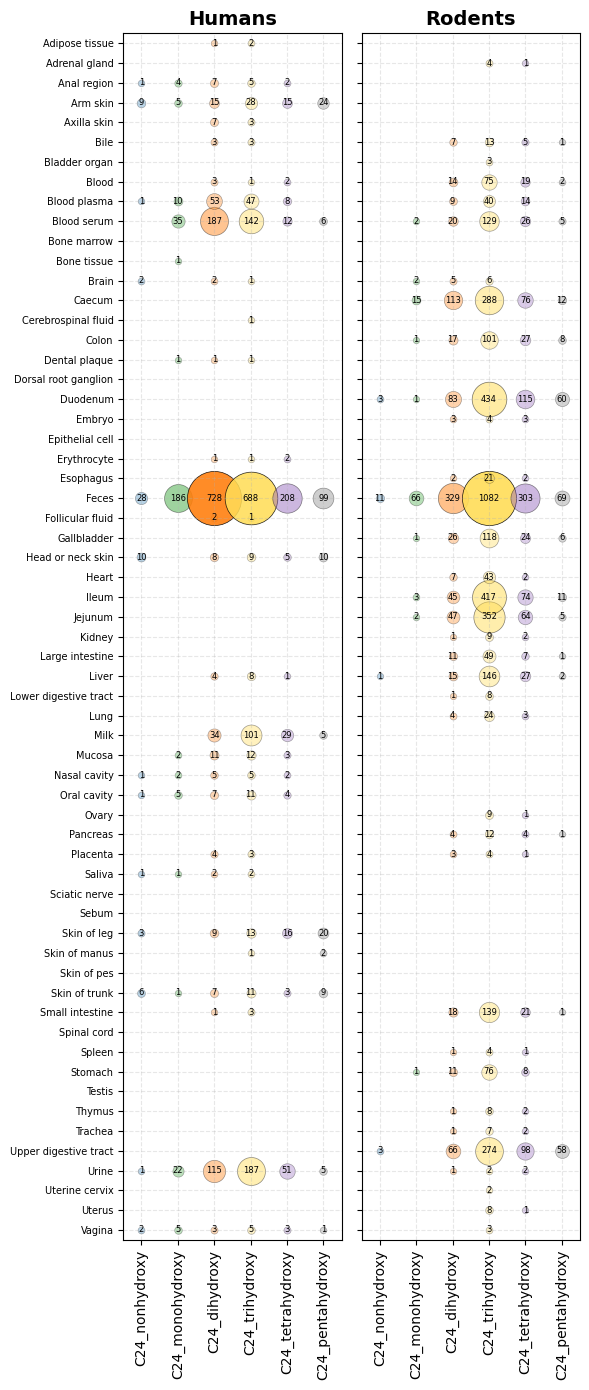

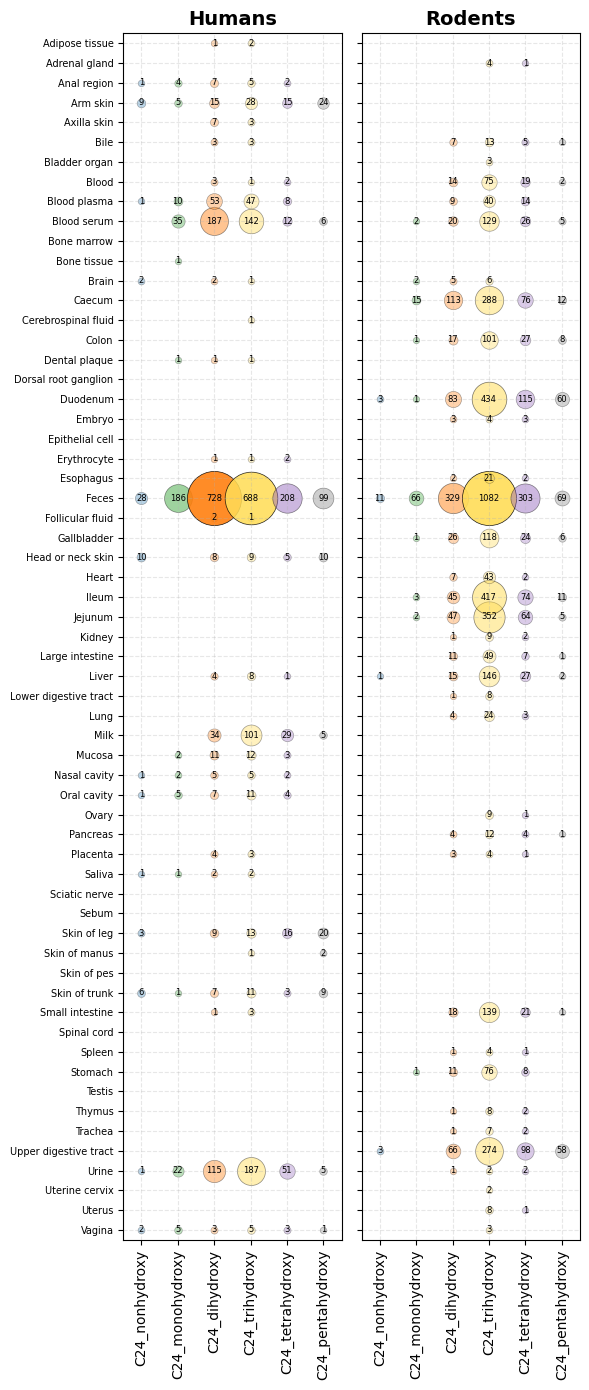

In [41]:
my_colors = {
    "C24_nonhydroxy":   "#1f77b4",
    "C24_monohydroxy":  "#2ca02c",
    "C24_dihydroxy":    "#ff7f0e",
    "C24_trihydroxy":   "#ffdd57",
    "C24_tetrahydroxy": "#9467bd",
    "C24_pentahydroxy": "#7f7f7f",
}

plot_bile_acids(
    humans_path=f"{PROJECT_DIR}/body_part_distribution/table_humans_no_artifacts.tsv",
    rodents_path=f"{PROJECT_DIR}/body_part_distribution/table_rodents_no_artifacts.tsv",
    which="both",
    sort_method="alphabetical",
    # cmap_name="tab20",
    groups=["C24"],
    custom_colors=my_colors,
    figsize=(6, 14),
    # save_path=f'{PROJECT_DIR}/body_part_distribution/Figures/BA_body_distribution_bubble_plot_C24_no_artifacts.pdf'
)

# SCANS

In [29]:
import pandas as pd

redu_merged = pd.read_csv(f'{PROJECT_DIR}/body_part_distribution/merged_filepaths_redu_metadata.tsv', sep='\t')

In [30]:
#consider only positive deltas or missing (for the C28s)
redu_merged = redu_merged[(redu_merged['delta_round'] > 0) | (redu_merged['delta_round'].isna())]

#import all the artifact files
c23_artifacts = pd.read_csv(f'{PROJECT_DIR}/Scripts_data_analysis/ISF_evaluation/TSV_and_HTML_files_artifacts/cores_combined_6_total/C23_combined_annotated_artifacts.tsv', sep='\t').drop_duplicates()
c24_artifacts = pd.read_csv(f'{PROJECT_DIR}/Scripts_data_analysis/ISF_evaluation/TSV_and_HTML_files_artifacts/cores_combined_6_total/C24_combined_annotated_artifacts.tsv', sep='\t').drop_duplicates()
c24_alkamine_artifacts = pd.read_csv(f'{PROJECT_DIR}/Scripts_data_analysis/ISF_evaluation/TSV_and_HTML_files_artifacts/cores_combined_6_total/C24_alkylamine_combined_annotated_artifacts.tsv', sep='\t').drop_duplicates()
c26_artifacts = pd.read_csv(f'{PROJECT_DIR}/Scripts_data_analysis/ISF_evaluation/TSV_and_HTML_files_artifacts/cores_combined_6_total/Aceto_combined_annotated_artifacts.tsv', sep='\t').drop_duplicates()
c27_artifacts = pd.read_csv(f'{PROJECT_DIR}/Scripts_data_analysis/ISF_evaluation/TSV_and_HTML_files_artifacts/cores_combined_6_total/C27_combined_annotated_artifacts.tsv', sep='\t').drop_duplicates()
c28_artifacts = pd.read_csv(f'{PROJECT_DIR}/Scripts_data_analysis/ISF_evaluation/TSV_and_HTML_files_artifacts/cores_combined_6_total/C28_alcohol_combined_annotated_artifacts.tsv', sep='\t').drop_duplicates()

#combine all of them vertically
artifacts_combined = pd.concat([c23_artifacts, c24_artifacts, c24_alkamine_artifacts, c26_artifacts, c27_artifacts, c28_artifacts], axis=0)

redu_merged = pd.merge(redu_merged, artifacts_combined[['identifier','is_artifact']], how='left', on=['identifier'])

#keep only the ones that are False (not artifacts)
redu_merged = redu_merged[redu_merged['is_artifact'] == False]

#drop duplicates
redu_merged = redu_merged.drop_duplicates()

/tmp/ipykernel_305358/1776708974.py:7: DtypeWarning: Columns (21) have mixed types. Specify dtype option on import or set low_memory=False.
  c24_alkamine_artifacts = pd.read_csv(f'{PROJECT_DIR}/Scripts_data_analysis/ISF_evaluation/TSV_and_HTML_files_artifacts/cores_combined_6_total/C24_alkylamine_combined_annotated_artifacts.tsv', sep='\t').drop_duplicates()


In [31]:
#create a column with BA class and delta mass rounded
redu_merged['BA_core_delta'] = redu_merged['core_std'] + '_' + redu_merged['delta_round'].astype(str)

#rename the ones that had to be split
redu_merged['core_std'] = redu_merged['core_std'].replace({
    'C24_trihydroxy_part1': 'C24_trihydroxy',
    'C24_trihydroxy_part2': 'C24_trihydroxy',
    'C24_trihydroxy_part3': 'C24_trihydroxy',
    'C24_alkylamine_trihydroxy_part1': 'C24_alkylamine_trihydroxy',
    'C24_alkylamine_trihydroxy_part2': 'C24_alkylamine_trihydroxy',
    'C24_alkylamine_trihydroxy_part3': 'C24_alkylamine_trihydroxy',
    'C24_alkylamine_trihydroxy_part4': 'C24_alkylamine_trihydroxy',
})

#split humans and rodents
#Humans
df_humans = redu_merged.loc[redu_merged['NCBITaxonomy'] == '9606|Homo sapiens']

#Rodents
list_rattus_mus = ['10088|Mus','10090|Mus musculus','10105|Mus minutoides','10114|Rattus','10116|Rattus norvegicus']
df_rodents = redu_merged[redu_merged['NCBITaxonomy'].isin(list_rattus_mus)]

#remove duplicates
df_humans = df_humans.drop_duplicates()
df_rodents = df_rodents.drop_duplicates()

In [32]:
counts_scans_humans = (
    df_humans.groupby(["UBERONBodyPartName", "core_std"])
      .size()
      .reset_index(name="count")
)

counts_scans_rodents = (
    df_rodents.groupby(["UBERONBodyPartName", "core_std"])
      .size()
      .reset_index(name="count")
)

# define the exact order you want (still using the pre-rename core_std names)
col_order = [
    'C23_monohydroxy', 'C23_dihydroxy', 'C23_trihydroxy',
    'C23_tetrahydroxy', 'C23_pentahydroxy', 'C24_nonhydroxy',
    'C24_monohydroxy', 'C24_dihydroxy', 'C24_trihydroxy',
    'C24_tetrahydroxy', 'C24_pentahydroxy',
    'C24_alkylamine_monohydroxy', 'C24_alkylamine_dihydroxy',
    'C24_alkylamine_trihydroxy', 'C24_alkylamine_tetrahydroxy',
    'C24_alkylamine_pentahydroxy', 'Aceto_dihydroxy',
    'C27_monohydroxy', 'C27_dihydroxy', 'C27_trihydroxy',
    'C27_tetrahydroxy', 'C27_pentahydroxy', 'C28_alcohol_1OH', 
    'C28_alcohol_2OH', 'C28_alcohol_3OH'
]

table_humans = (
    counts_scans_humans
      .pivot(index="UBERONBodyPartName", columns="core_std", values="count")
      .reindex(columns=col_order, fill_value=0)
      .fillna(0)
      .astype(int)
      .reset_index()
)

table_rodents = (
    counts_scans_rodents
      .pivot(index="UBERONBodyPartName", columns="core_std", values="count")
      .reindex(columns=col_order, fill_value=0)
      .fillna(0)
      .astype(int)
      .reset_index()
)

In [33]:
#some renaming for standardizing
table_humans.columns = table_humans.columns.str.replace('alkylamine', 'alkamine').str.replace('Aceto_', 'C26_')
table_rodents.columns = table_rodents.columns.str.replace('alkylamine', 'alkamine').str.replace('Aceto_', 'C26_')

In [34]:
table_humans.to_csv(f'{PROJECT_DIR}/body_part_distribution/table_humans_scans_no_artifacts.tsv', sep='\t', index=False)
table_rodents.to_csv(f'{PROJECT_DIR}/body_part_distribution/table_rodents_scans_no_artifacts.tsv', sep='\t', index=False)

# Plot

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Fixed column order (C24 classes) ---
class_order = [
    'C23_monohydroxy', 'C23_dihydroxy', 'C23_trihydroxy',
    'C23_tetrahydroxy', 'C23_pentahydroxy', 'C24_nonhydroxy',
    'C24_monohydroxy', 'C24_dihydroxy', 'C24_trihydroxy',
    'C24_tetrahydroxy', 'C24_pentahydroxy',
    'C24_alkamine_monohydroxy', 'C24_alkamine_dihydroxy',
    'C24_alkamine_trihydroxy', 'C24_alkamine_tetrahydroxy',
    'C24_alkamine_pentahydroxy', 'C26_dihydroxy',
    'C27_monohydroxy', 'C27_dihydroxy', 'C27_trihydroxy',
    'C27_tetrahydroxy', 'C27_pentahydroxy', 
    'C28_alcohol_1OH', 'C28_alcohol_2OH', 'C28_alcohol_3OH',
]

# Named groups -> (include_prefixes, exclude_prefixes).
# "C24" means C24 but NOT the alkylamine sub-series; "C24_alkylamine" is that sub-series.
COLUMN_GROUPS = {
    "C23":            (("C23_",),            ()),
    "C24":            (("C24_",),            ("C24_alkamine_",)),
    "C24_alkamine": (("C24_alkamine_",), ()),
    "C26":            (("C26_",),            ()),
    "C27":            (("C27_",),            ()),
    "C28_alcohol":    (("C28_alcohol_",),    ()),
}

anatomical_order = [
    # Head/Brain
    'brain','cerebrospinal fluid','eye','retina','nasal cavity','oral cavity',
    # Glands in head/neck
    'saliva','dental plaque',
    # Respiratory
    'trachea','lung','alveolar system',
    # Cardiovascular
    'heart','blood','blood plasma','blood serum','erythrocyte','megakaryocyte',
    # Digestive - upper
    'upper digestive tract','esophagus','stomach',
    # Digestive - intestines
    'small intestine','duodenum','jejunum','ileum','large intestine','colon','caecum',
    'lower digestive tract','anal region',
    # Digestive - associated organs
    'liver','bile','gallbladder','pancreas',
    # Urinary
    'kidney','bladder organ','urine',
    # Excretion
    'feces',
    # Reproductive
    'testis','semen','ovary','follicular fluid','uterus','uterine cervix',
    'placenta','vagina','amniotic fluid',
    # Endocrine/Immune
    'adrenal gland','thymus','spleen',
    # Skeletal/Connective
    'bone tissue','bone marrow',
    # Muscle
    'muscle of leg',
    # Nervous (peripheral)
    'dorsal root ganglion','sciatic nerve','cortex',
    # Skin/Integument
    'zone of skin','skin of trunk','axilla skin','arm skin','head or neck skin',
    'skin of leg','skin of manus','skin of pes','sebum',
    # Tissue types
    'adipose tissue','mucosa','epithelial cell',
    # Development
    'embryo','embryonic cell (metazoa)','stem cell',
    # Secretions
    'milk',
]

def select_classes(groups):
    """Return the subset of class_order matching the requested groups.

    groups may be:
      - None                 -> all classes
      - a string             -> single group name (or raw prefix)
      - a list of strings    -> group names from COLUMN_GROUPS; anything
                                not a known group name is treated as a
                                literal prefix.
    Output order always follows class_order.
    """
    if groups is None:
        return list(class_order)
    if isinstance(groups, str):
        groups = [groups]

    selected = []
    for col in class_order:
        for g in groups:
            if g in COLUMN_GROUPS:
                inc, exc = COLUMN_GROUPS[g]
                if col.startswith(inc) and not col.startswith(exc):
                    selected.append(col)
                    break
            elif col.startswith(g):   # raw prefix fallback
                selected.append(col)
                break
    return selected

def plot_bile_acids(
    humans_path,
    rodents_path,
    which="humans",
    sort_method="alphabetical",
    cmap_name="tab20",
    custom_colors=None,      # NEW: dict {class_name: color}, overrides cmap
    groups=None,
    figsize=None,
    save_path=None,
):
    plt.close('all')

    df_humans = pd.read_csv(humans_path, sep="\t")
    df_rodents = pd.read_csv(rodents_path, sep="\t")

    df_humans = df_humans[df_humans['UBERONBodyPartName'] != 'missing value']
    df_rodents = df_rodents[df_rodents['UBERONBodyPartName'] != 'missing value']

    # --- Pick which class columns to plot ---
    requested = select_classes(groups)
    available = set(df_humans.columns).union(df_rodents.columns)
    selected = [c for c in requested if c in available]
    missing = [c for c in requested if c not in available]
    if missing:
        print(f"Warning: requested classes not found in data, skipping: {missing}")
    if not selected:
        raise ValueError("No matching columns for the requested groups.")

    # Keep UBERON col + selected classes; add any missing-in-one-table class as 0
    def prep_columns(df):
        out = df.set_index("UBERONBodyPartName")
        for c in selected:
            if c not in out.columns:
                out[c] = 0
        return out[selected].reset_index()

    df_humans = prep_columns(df_humans)
    df_rodents = prep_columns(df_rodents)

    # --- Body-part ordering ---
    present = set(df_humans["UBERONBodyPartName"]).union(df_rodents["UBERONBodyPartName"])
    if sort_method == "anatomical":
        ordered_body_parts = [bp for bp in anatomical_order if bp in present][::-1]
    else:
        ordered_body_parts = sorted(present, reverse=True)

    def order_and_fill(df, body_part_order):
        return (
            df.set_index("UBERONBodyPartName")[selected]
              .reindex(body_part_order)
              .fillna(0)
              .astype(float)
              .reset_index()
        )

    df_humans = order_and_fill(df_humans, ordered_body_parts)
    df_rodents = order_and_fill(df_rodents, ordered_body_parts)
    pretty_labels = [bp.capitalize() for bp in ordered_body_parts]

    # --- Colors built from the selected subset (max contrast per figure) ---
    cmap = plt.get_cmap(cmap_name)
    n = len(selected)
    if hasattr(cmap, "colors") and len(getattr(cmap, "colors", [])) >= n:
        cmap_colors = {cls: cmap(i) for i, cls in enumerate(selected)}
    else:
        cmap_colors = {cls: cmap(i / max(n - 1, 1)) for i, cls in enumerate(selected)}

    if custom_colors:
        class_colors = {}
        uncolored = []
        for cls in selected:
            if cls in custom_colors:
                class_colors[cls] = custom_colors[cls]
            else:
                class_colors[cls] = cmap_colors[cls]   # fallback for missing
                uncolored.append(cls)
        if uncolored:
            print(f"Note: no custom color for {uncolored}; "
                  f"using '{cmap_name}' for those.")
    else:
        class_colors = cmap_colors

    def bubble_plot(df, title, ax):
        x_pos = np.arange(len(selected))
        y_pos = np.arange(len(pretty_labels))
        vals = df[selected].to_numpy()
        vmax = vals.max() if np.isfinite(vals).any() and vals.max() > 0 else 1.0
        min_size, size_scale = 20, 1500

        for j, cls in enumerate(selected):
            for i, val in enumerate(vals[:, j]):
                if val > 0:
                    size = min_size + (val / vmax) * size_scale
                    alpha = 0.3 + 0.6 * (val / vmax)
                    ax.scatter(j, i, s=size, c=[class_colors[cls]], alpha=alpha,
                               edgecolors="black", linewidth=0.5)
                    ax.text(j, i, f'{val:.0f}', ha='center', va='center',
                            fontsize=6, color='black')
        
        # add margin so edge bubbles aren't clipped
        ax.set_xlim(-0.5, len(selected) - 0.5)
        ax.set_ylim(-0.5, len(pretty_labels) - 0.5)
        ax.margins(x=0.15, y=0.02)

        ax.set_xticks(x_pos)
        ax.set_xticklabels(selected, rotation=90, ha="center")
        ax.set_yticks(y_pos)
        ax.set_yticklabels(pretty_labels, fontsize=7)
        ax.set_title(title, fontsize=14, fontweight="bold")
        ax.grid(axis="both", alpha=0.3, linestyle="--")

    # def add_class_legend(ax):
    #     handles = [
    #         plt.Line2D([0], [0], marker="s", color="w", markerfacecolor=color,
    #                    markersize=15, label=cls)
    #         for cls, color in class_colors.items()
    #     ]
    #     ax.legend(handles=handles, title="BA class",
    #               bbox_to_anchor=(1.05, 1), loc="upper left")

    if figsize is None:
        figsize = (10, 12) if which == "both" else (6, 12)

    if which == "both":
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize, sharey=True)
        bubble_plot(df_humans, "Humans", ax1)
        bubble_plot(df_rodents, "Rodents", ax2)
        # add_class_legend(ax2)
    else:
        fig, ax = plt.subplots(1, 1, figsize=figsize)
        bubble_plot(df_humans if which == "humans" else df_rodents,
                    "Humans" if which == "humans" else "Rodents", ax)
        # add_class_legend(ax)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
    
    return fig

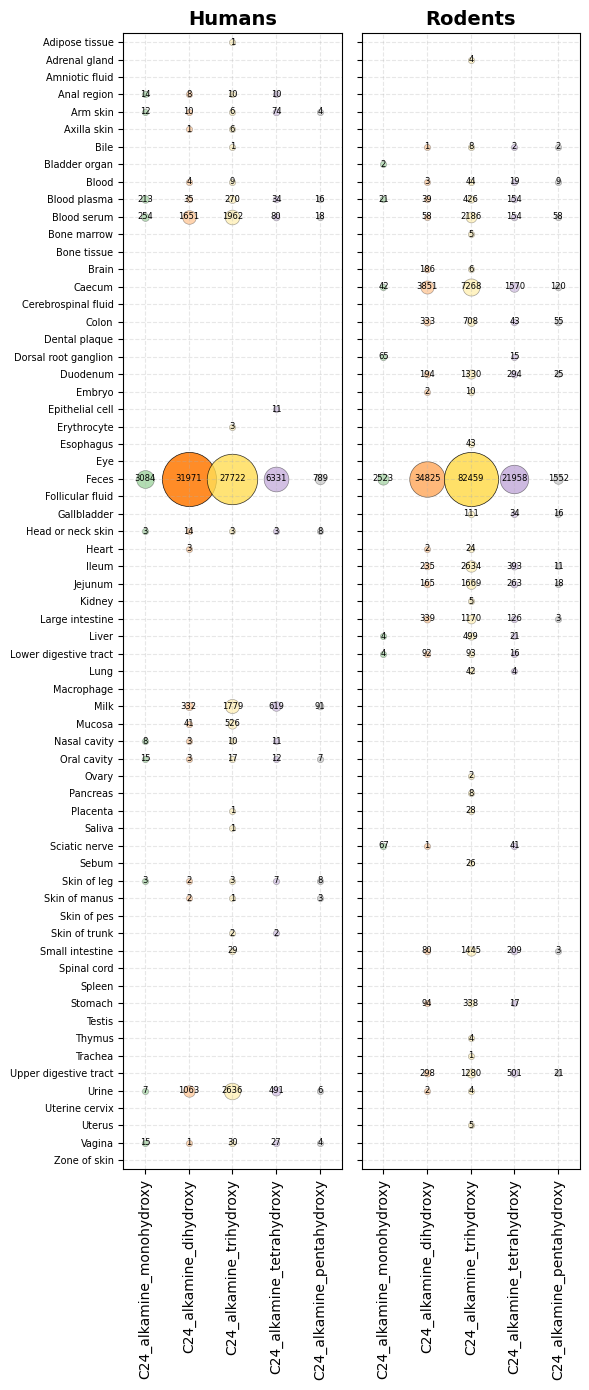

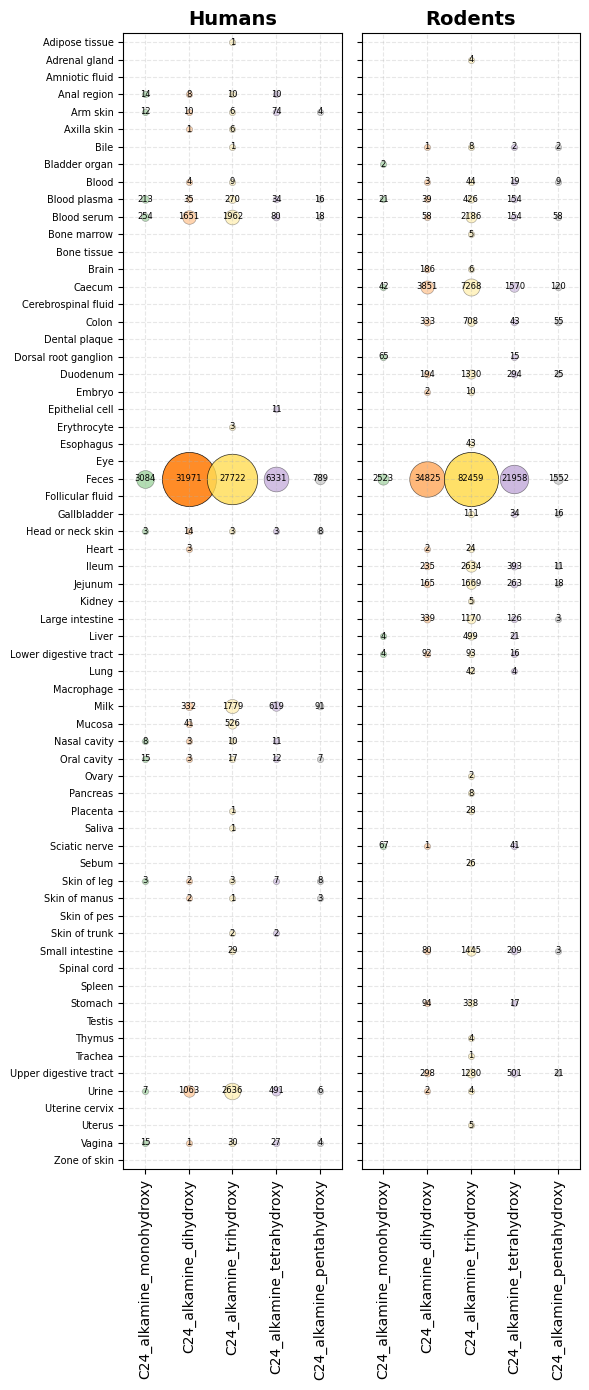

In [37]:
my_colors = {
    "C24_alkamine_nonhydroxy":   "#1f77b4",
    "C24_alkamine_monohydroxy":  "#2ca02c",
    "C24_alkamine_dihydroxy":    "#ff7f0e",
    "C24_alkamine_trihydroxy":   "#ffdd57",
    "C24_alkamine_tetrahydroxy": "#9467bd",
    "C24_alkamine_pentahydroxy": "#7f7f7f",
}

# my_colors = {
#     "C28_alcohol_1OH":   "#e377c2",
#     "C28_alcohol_2OH":   "#17becf",
#     "C28_alcohol_3OH":   "#ddb892",
# }

plot_bile_acids(
    humans_path=f"{PROJECT_DIR}/body_part_distribution/table_humans_scans_no_artifacts.tsv",
    rodents_path=f"{PROJECT_DIR}/body_part_distribution/table_rodents_scans_no_artifacts.tsv",
    which="both",
    sort_method="alphabetical",
    # cmap_name="tab20",
    groups=["C24_alkamine"],
    custom_colors=my_colors,
    figsize=(6, 14),
    # save_path=f'{PROJECT_DIR}/body_part_distribution/Figures/BA_body_distribution_bubble_plot_C24_alkamine_scans_no_artifacts.pdf'
)